In [ ]:
import torch
from PIL import Image
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection
import cv2


# model_id = "IDEA-Research/grounding-dino-tiny"
model_id = "IDEA-Research/grounding-dino-base"
device = "cuda"

processor = AutoProcessor.from_pretrained(model_id)
model = AutoModelForZeroShotObjectDetection.from_pretrained(model_id).to(device)

SOURCE_IMAGE_PATH = r"D:\3d-recon\datasets\ASARoomImage\d03.jpg"
# image = Image.open(SOURCE_IMAGE_PATH).convert("RGB")
image = cv2.imread(SOURCE_IMAGE_PATH)
# Check for cats and remote controls
text_labels = ["walls."]

inputs = processor(images=image, text=text_labels, return_tensors="pt").to(device)
with torch.no_grad():
    outputs = model(**inputs)

results = processor.post_process_grounded_object_detection(
    outputs,
    inputs.input_ids,
    box_threshold=0.25,
    text_threshold=0.25,
    target_sizes=[image.size[::-1]]
)

result = results[0]
for box, score, labels in zip(result["boxes"], result["scores"], result["labels"]):
    box = [round(x, 2) for x in box.tolist()]
    print(f"Detected {labels} with confidence {round(score.item(), 3)} at location {box}")

In [1]:
from utils_dino_final_huggingface import *
import time

start_time = time.time()

SOURCE_IMAGE_PATH = r"D:\3d-recon\datasets\ASARoomImage\d03.jpg"

In [2]:
wall_bboxes, wall_selected_points = get_wall_bboxes_points(SOURCE_IMAGE_PATH)

print("wall_bboxes", wall_bboxes)
print("wall_selected_points", wall_selected_points)

# print(type(wall_bboxes))
# print(wall_bboxes.shape)

# print(type(wall_selected_points))
# print(len(wall_selected_points))

Getting wall mask from  D:\3d-recon\datasets\ASARoomImage\d03.jpg
wall_bboxes [[7.3951721e-01 2.7149200e-01 6.3487451e+02 1.1533586e+03]
 [6.2930426e+02 3.0708652e+02 1.3671998e+03 7.3335571e+02]
 [1.3618854e+03 1.6390038e+01 1.9192394e+03 7.8894092e+02]]
wall_selected_points [[183, 500], [1065, 673], [1694, 399]]


In [3]:
(floor_bboxes, 
 floor_selected_points, 
 rug_bboxes,
 rug_to_floor_indices) = get_floor_bboxes_points_with_rug(SOURCE_IMAGE_PATH)

print("floor_bboxes", floor_bboxes)
print("floor_selected_points", floor_selected_points)

print("rug_bboxes", rug_bboxes)
print("rug_to_floor_indices", rug_to_floor_indices)

# print(type(floor_bboxes))
# print(floor_bboxes.shape)

# print(type(floor_selected_points))
# print(len(floor_selected_points))

# print(type(rug_bboxes))
# print(rug_bboxes.shape)

RUG:  0
There is overlap
Subtract rug from floor area NOT OK. Revert to original Floor!
RUG:  1
There is overlap
Subtract rug from floor area NOT OK. Revert to original Floor!
floor_bboxes [[ 894.4893   761.6349  1273.1968  1002.551  ]
 [ 276.14816  625.9015   604.54785  999.46655]]
floor_selected_points [[1166, 884], [420, 745]]
rug_bboxes []
rug_to_floor_indices []


# Output for Client

In [4]:
output = {'wall_bboxes': wall_bboxes,
          'wall_selected_points':wall_selected_points,
          'floor_bboxes':floor_bboxes,
          'floor_selected_points': floor_selected_points,
          'rug_bboxes': rug_bboxes,
          'rug_to_floor_indices':rug_to_floor_indices}
print(time.time()-start_time)
output

65.46868705749512


{'wall_bboxes': array([[7.3951721e-01, 2.7149200e-01, 6.3487451e+02, 1.1533586e+03],
        [6.2930426e+02, 3.0708652e+02, 1.3671998e+03, 7.3335571e+02],
        [1.3618854e+03, 1.6390038e+01, 1.9192394e+03, 7.8894092e+02]],
       dtype=float32),
 'wall_selected_points': [[183, 500], [1065, 673], [1694, 399]],
 'floor_bboxes': array([[ 894.4893 ,  761.6349 , 1273.1968 , 1002.551  ],
        [ 276.14816,  625.9015 ,  604.54785,  999.46655]], dtype=float32),
 'floor_selected_points': [[1166, 884], [420, 745]],
 'rug_bboxes': array([], dtype=float64),
 'rug_to_floor_indices': []}

In [5]:
import time

start_time = time.time()

image = cv2.imread(SOURCE_IMAGE_PATH)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
print(image.shape)

checkpoint = r"./sam_vit_h_4b8939.pth"

model_type = "vit_h"
sam = sam_model_registry[model_type](checkpoint=checkpoint)

print(time.time()-start_time)

sam.to(device='cuda')
predictor = SamPredictor(sam)
predictor.set_image(image)
image_embedding = predictor.get_image_embedding().cpu().numpy()

np.save("image_embedding_vith.npy", image_embedding)

print(time.time()-start_time)

(1280, 1920, 3)


3.0566811561584473
4.070177316665649


In [6]:
print(image.shape)

(1280, 1920, 3)


In [7]:
def get_onnx_mask_from_bboxes(bboxes, ort_session):

    onnx_coord = np.concatenate([xyxy.reshape(1,2,2) for xyxy in bboxes], axis=0)#[None, :, :]
    onnx_label = np.concatenate([np.array([2,3]).reshape(1,2) for _ in range(bboxes.shape[0])], axis=0).astype(np.float32) #[None, :].astype(np.float32)

    print(onnx_coord.shape)
    print(onnx_label.shape)

    print(image.shape[:2])

    onnx_coord = predictor.transform.apply_coords(onnx_coord, image.shape[:2]).astype(np.float32)

    onnx_mask_input = np.zeros((1, 1, 256, 256), dtype=np.float32)
    onnx_has_mask_input = np.zeros(1, dtype=np.float32)

    ort_inputs = {
        "image_embeddings": image_embedding,
        "point_coords": onnx_coord,
        "point_labels": onnx_label,
        "mask_input": onnx_mask_input,
        "has_mask_input": onnx_has_mask_input,
        "orig_im_size": np.array(image.shape[:2], dtype=np.float32)
    }

    masks, _, _ = ort_session.run(None, ort_inputs)
    masks = masks > predictor.model.mask_threshold
    print(masks.shape)

    return masks

In [8]:
import onnxruntime

onnx_model_path = "sam_onnx_vith_batch.onnx"
ort_session = onnxruntime.InferenceSession(onnx_model_path)
wall_masks = get_onnx_mask_from_bboxes(wall_bboxes, ort_session)

ort_session = onnxruntime.InferenceSession(onnx_model_path)
floor_masks = get_onnx_mask_from_bboxes(floor_bboxes, ort_session)

if len(rug_bboxes)>0:
    ort_session = onnxruntime.InferenceSession(onnx_model_path)
    rug_masks = get_onnx_mask_from_bboxes(rug_bboxes, ort_session)

(3, 2, 2)
(3, 2)
(1280, 1920)
(3, 1, 1280, 1920)
(2, 2, 2)
(2, 2)
(1280, 1920)
(2, 1, 1280, 1920)


In [9]:
# Step 1: Convert to uint8 (0 and 255)
mask_uint8 = (wall_masks[0].squeeze() * 255).astype(np.uint8)  # shape becomes (2657, 1920)

# Step 2: Save as JPG
cv2.imwrite("wall_mask.jpg", mask_uint8)

True

(1, 1280, 1920)
(1, 1280, 1920)
(1, 1280, 1920)


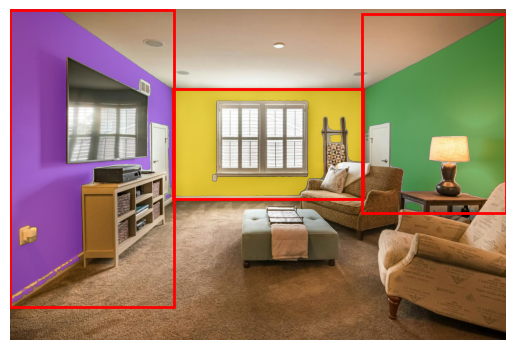

True

In [10]:
plt.imshow(image)

for mask, bbox in zip(wall_masks, wall_bboxes):
    print(mask.shape)
    show_mask(mask, plt.gca())
    show_box(bbox, plt.gca())
plt.axis('off')
plt.show()

# Step 1: Convert to uint8 (0 and 255)
mask_uint8 = (mask.squeeze() * 255).astype(np.uint8)  # shape becomes (2657, 1920)

# Step 2: Save as JPG
cv2.imwrite("mask.jpg", mask_uint8)

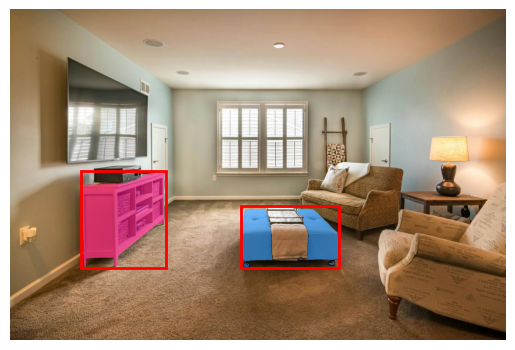

In [11]:
plt.imshow(image)

for mask, bbox in zip(floor_masks, floor_bboxes):
    show_mask(mask, plt.gca())
    show_box(bbox, plt.gca())
plt.axis('off')
plt.show()

In [13]:
if len(rug_bboxes)>0:
    plt.imshow(image)

    for mask, bbox in zip(rug_masks, rug_bboxes):
        show_mask(mask, plt.gca())
        show_box(bbox, plt.gca())
    plt.axis('off')
    plt.show()